<a href="https://colab.research.google.com/github/Mobina2003/Analysis-of-stock-market-data/blob/main/project_realstate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pmdarima arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 37.4 MB/s eta 0:00:00


## Load and Inspect Data

Load the `RealState.csv` file into a pandas DataFrame, parse the date column, and set it as the index. Inspect the data for its structure, data types, and initial patterns.


In [ ]:
import pandas as pd

#Load the RealState.csv file, parsing 'Date' as dates and setting it as the index
df = pd.read_csv('RealState.csv', parse_dates=['Date'], index_col='Date')

#Display the first few rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

#Print the DataFrame's information to check data types and non-null counts
print("\nDataFrame Info:")
df.info()

#Print a summary of descriptive statistics for the numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
                Value
Date                 
1990-01-31  50.993428
1990-02-28  53.773471
1990-03-31  58.323580
1990-04-30  61.196060
1990-05-31  56.659896

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 360 entries, 1990-01-31 to 2019-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Value   360 non-null    float64
dtypes: float64(1)
memory usage: 5.6 KB

Descriptive Statistics:
            Value
count  360.000000
mean    58.978307
std      7.868033
min     41.534578
25%     53.191804
50%     59.269236
75%     64.426393
max     78.500712


## Handle Missing Values and Frequency

Check for any missing values in the time series and handle them appropriately. Ensure the time series has a consistent monthly frequency, resampling if necessary.


In [ ]:
print('Checking for missing values:')
print(df.isnull().sum())

#Ensure consistent monthly frequency (Month End)
#'ME' sets the frequency to month end. If there are any missing months, it will insert NaNs.
df_resampled = df.asfreq('ME')

#If asfreq introduced NaNs, it means there were gaps. Handle them with ffill.
#If there were no NaNs initially and asfreq didn't introduce any, this step effectively does nothing.
if df_resampled.isnull().any().any():
    print("\nGaps found in time series. Forward-filling missing values...")
    df_resampled = df_resampled.ffill()
else:
    print("\nTime series already has a consistent monthly frequency with no gaps.")

df = df_resampled.copy()

print('\nFirst 5 rows after frequency check and potential filling:')
print(df.head())
print('\nLast 5 rows after frequency check and potential filling:')
print(df.tail())

Checking for missing values:
Value    0
dtype: int64

Time series already has a consistent monthly frequency with no gaps.

First 5 rows after frequency check and potential filling:
                Value
Date                 
1990-01-31  50.993428
1990-02-28  53.773471
1990-03-31  58.323580
1990-04-30  61.196060
1990-05-31  56.659896

Last 5 rows after frequency check and potential filling:
                Value
Date                 
2019-08-31  61.744941
2019-09-30  60.834770
2019-10-31  59.272683
2019-11-30  61.617234
2019-12-31  62.295538


## Visualize Time Series Components

Generate a plot of the time series data to visually identify trends, seasonality, and any irregular components.


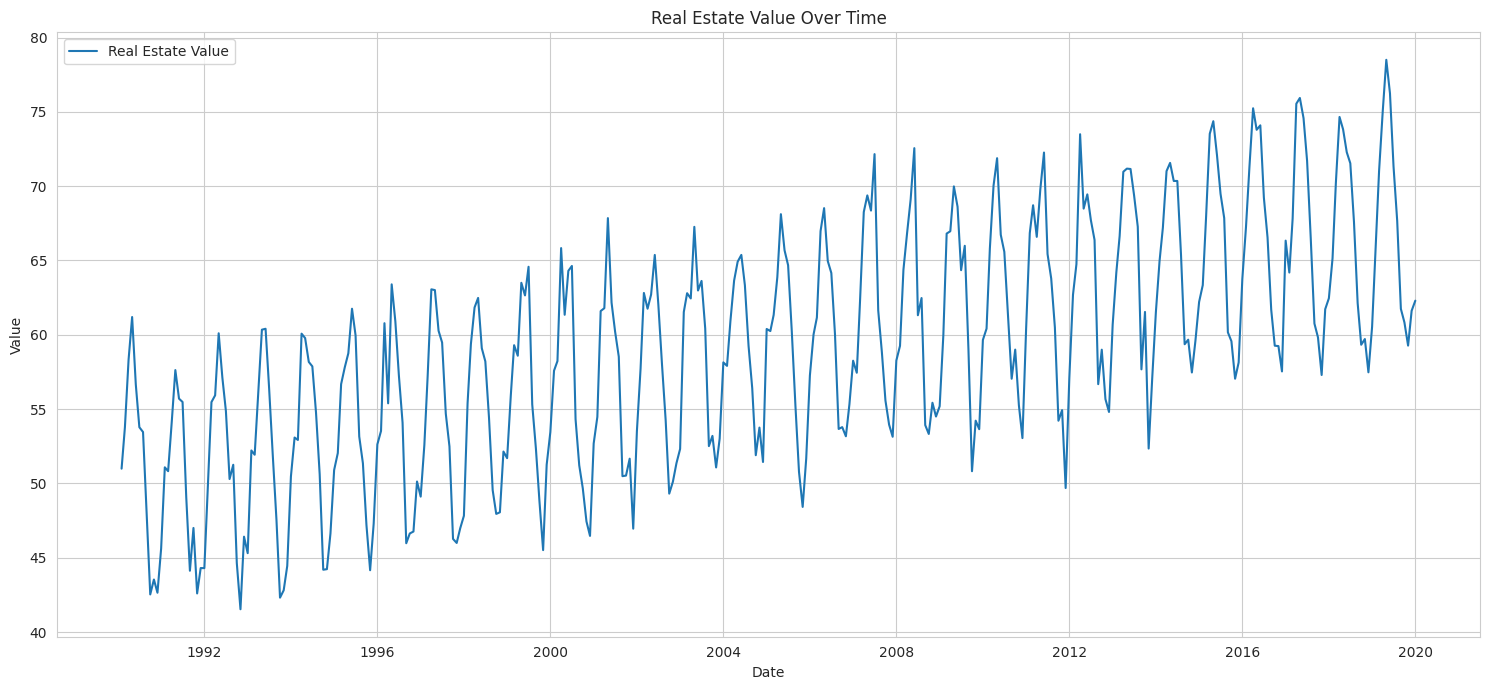

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set plot style
sns.set_style('whitegrid')

#Create the time series plot
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Value'], label='Real Estate Value')
plt.title('Real Estate Value Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Decompose Time Series

Decompose the time series into its trend, seasonal, and residual components using a seasonal decomposition method to better understand its underlying patterns.


<Figure size 1500x1000 with 0 Axes>

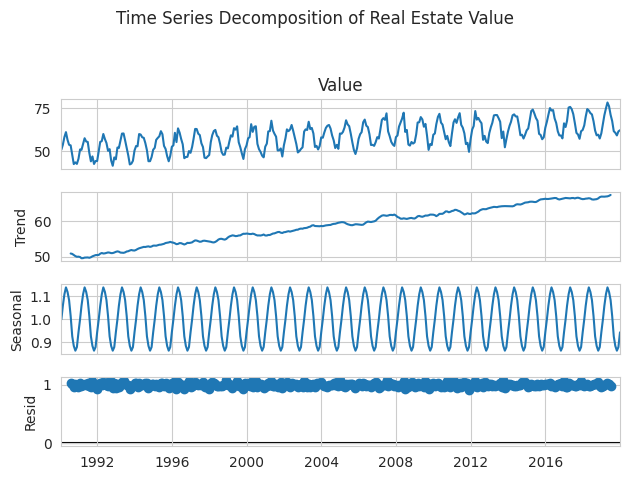

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

#Perform seasonal decomposition
decomposition = seasonal_decompose(df['Value'], model='multiplicative', period=12)

#Plot the decomposed components
plt.figure(figsize=(15, 10))
decomposition.plot()
plt.suptitle('Time Series Decomposition of Real Estate Value', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

## Test for Stationarity (ADF Test)

Perform an Augmented Dickey-Fuller (ADF) test on the time series to statistically check for stationarity.


In [ ]:
from statsmodels.tsa.stattools import adfuller

#Perform the Augmented Dickey-Fuller test
print("Performing Augmented Dickey-Fuller Test...")
result = adfuller(df['Value'])

#Extract and print the test results
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'    {key}: {value:.4f}')

#Interpret the results
alpha = 0.05
if result[1] <= alpha:
    print(f"\nConclusion: The p-value ({result[1]:.4f}) is less than or equal to the significance level ({alpha}).")
    print("We reject the null hypothesis, meaning the time series is likely stationary.")
else:
    print(f"\nConclusion: The p-value ({result[1]:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis, meaning the time series is likely non-stationary and requires differencing.")

Performing Augmented Dickey-Fuller Test...
ADF Statistic: -0.3195
p-value: 0.9227
Critical Values:
    1%: -3.4494
    5%: -2.8699
    10%: -2.5712

Conclusion: The p-value (0.9227) is greater than the significance level (0.05).
We fail to reject the null hypothesis, meaning the time series is likely non-stationary and requires differencing.


## Determine Differencing Orders

Determine the appropriate non-seasonal (d) and seasonal (D) differencing orders for the SARIMA model based on the stationarity test and visual inspection of the time series and its decomposed components.


In [ ]:
df['Value_diff1'] = df['Value'].diff(1)
print("First-order non-seasonal differencing applied. Head of the new series:")
print(df['Value_diff1'].head())


First-order non-seasonal differencing applied. Head of the new series:
Date
1990-01-31         NaN
1990-02-28    2.780043
1990-03-31    4.550109
1990-04-30    2.872479
1990-05-31   -4.536163
Freq: ME, Name: Value_diff1, dtype: float64


In [ ]:
print("Performing Augmented Dickey-Fuller Test on the differenced series...")
result_diff = adfuller(df['Value_diff1'].dropna())

#Extract and print the test results
print(f'ADF Statistic: {result_diff[0]:.4f}')
print(f'p-value: {result_diff[1]:.4f}')
print('Critical Values:')
for key, value in result_diff[4].items():
    print(f'    {key}: {value:.4f}')

#Interpret the results
alpha = 0.05
if result_diff[1] <= alpha:
    print(f"\nConclusion: The p-value ({result_diff[1]:.4f}) is less than or equal to the significance level ({alpha}).")
    print("We reject the null hypothesis, meaning the differenced time series is likely stationary.")
else:
    print(f"\nConclusion: The p-value ({result_diff[1]:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis, meaning the differenced time series is still non-stationary and may require further differencing.")

Performing Augmented Dickey-Fuller Test on the differenced series...
ADF Statistic: -13.1257
p-value: 0.0000
Critical Values:
    1%: -3.4494
    5%: -2.8699
    10%: -2.5712

Conclusion: The p-value (0.0000) is less than or equal to the significance level (0.05).
We reject the null hypothesis, meaning the differenced time series is likely stationary.


Apply seasonal differencing with a period of 12 to the `Value_diff1` series to remove the seasonal component, and then display the head of this newly differenced series.



In [ ]:
df['Value_diff12_diff1'] = df['Value_diff1'].diff(12)
print("First-order seasonal differencing (period 12) applied to the non-seasonally differenced series. Head of the new series:")
print(df['Value_diff12_diff1'].head())

First-order seasonal differencing (period 12) applied to the non-seasonally differenced series. Head of the new series:
Date
1990-01-31   NaN
1990-02-28   NaN
1990-03-31   NaN
1990-04-30   NaN
1990-05-31   NaN
Freq: ME, Name: Value_diff12_diff1, dtype: float64


Perform an ADF test on the twice-differenced series to confirm stationarity after both non-seasonal and seasonal differencing.



In [ ]:
print("Performing Augmented Dickey-Fuller Test on the twice differenced series...")
result_diff12_diff1 = adfuller(df['Value_diff12_diff1'].dropna()) # .dropna() to handle NaNs

#Extract and print the test results
print(f'ADF Statistic: {result_diff12_diff1[0]:.4f}')
print(f'p-value: {result_diff12_diff1[1]:.4f}')
print('Critical Values:')
for key, value in result_diff12_diff1[4].items():
    print(f'    {key}: {value:.4f}')

#Interpret the results
alpha = 0.05
if result_diff12_diff1[1] <= alpha:
    print(f"\nConclusion: The p-value ({result_diff12_diff1[1]:.4f}) is less than or equal to the significance level ({alpha}).")
    print("We reject the null hypothesis, meaning the twice differenced time series is likely stationary.")
else:
    print(f"\nConclusion: The p-value ({result_diff12_diff1[1]:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis, meaning the twice differenced time series is still non-stationary and may require further differencing.")

Performing Augmented Dickey-Fuller Test on the twice differenced series...
ADF Statistic: -8.7367
p-value: 0.0000
Critical Values:
    1%: -3.4503
    5%: -2.8703
    10%: -2.5715

Conclusion: The p-value (0.0000) is less than or equal to the significance level (0.05).
We reject the null hypothesis, meaning the twice differenced time series is likely stationary.


## Plot ACF and PACF for Model Orders

Generate Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots of the differenced series. These plots will help in identifying potential non-seasonal (p, q) and seasonal (P, Q) orders for the SARIMA model.


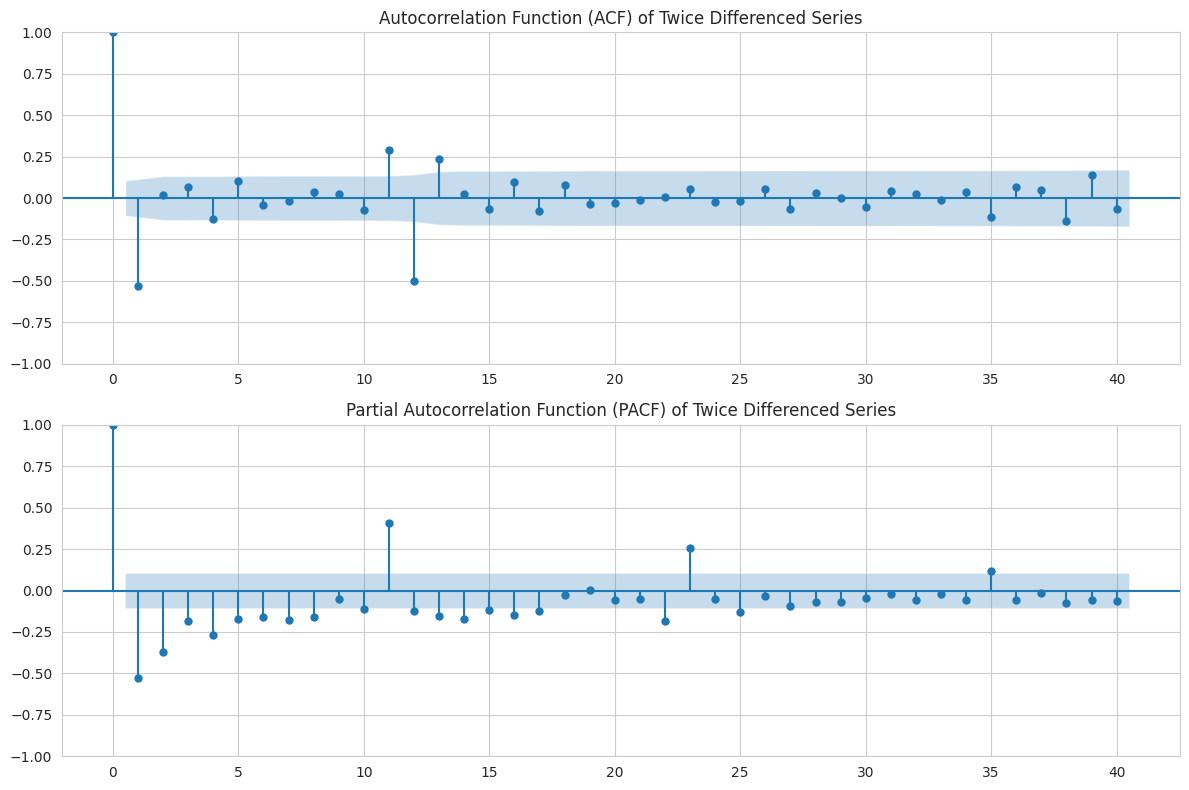

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

#Drop NaN values that resulted from differencing
differenced_series = df['Value_diff12_diff1'].dropna()

#Create subplots for ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#Plot ACF
plot_acf(differenced_series, ax=axes[0], lags=40)
axes[0].set_title('Autocorrelation Function (ACF) of Twice Differenced Series')

#Plot PACF
plot_pacf(differenced_series, ax=axes[1], lags=40)
axes[1].set_title('Partial Autocorrelation Function (PACF) of Twice Differenced Series')

plt.tight_layout()
plt.show()


## SARIMA Model Selection and Training

Select the appropriate SARIMA (p, d, q)(P, D, Q, s) parameters based on the ACF/PACF plots, stationarity tests, and seasonal period. Train the SARIMA model using the selected parameters.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# p=1, d=1 (from ADF test on original data), q=2 (from ACF/PACF)
order = (1, 1, 2)

#P=1 (from ACF/PACF), D=1 (from ADF test on seasonally differenced data), Q=1 (from ACF/PACF), s=12
seasonal_order = (1, 1, 1, 12)

print(f"SARIMA Model Order: {order}")
print(f"SARIMA Seasonal Order: {seasonal_order}")

#Instantiate and train the SARIMAX model
model = SARIMAX(df['Value'], order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False) # Set disp=False to suppress convergence messages

#Print the model summary
print(model_fit.summary())


SARIMA Model Order: (1, 1, 2)
SARIMA Seasonal Order: (1, 1, 1, 12)
                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  360
Model:             SARIMAX(1, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -697.461
Date:                              Mon, 06 Jul 2026   AIC                           1406.921
Time:                                      19:44:42   BIC                           1429.752
Sample:                                  01-31-1990   HQIC                          1416.026
                                       - 12-31-2019                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7095      1.55

## Evaluate SARIMA Model

Evaluate the performance of the trained SARIMA model using appropriate metrics such as AIC, BIC, and by forecasting on a hold-out test set to calculate error metrics like RMSE or MAE. Provide a forecast visualization.


Plotting SARIMA model diagnostics...


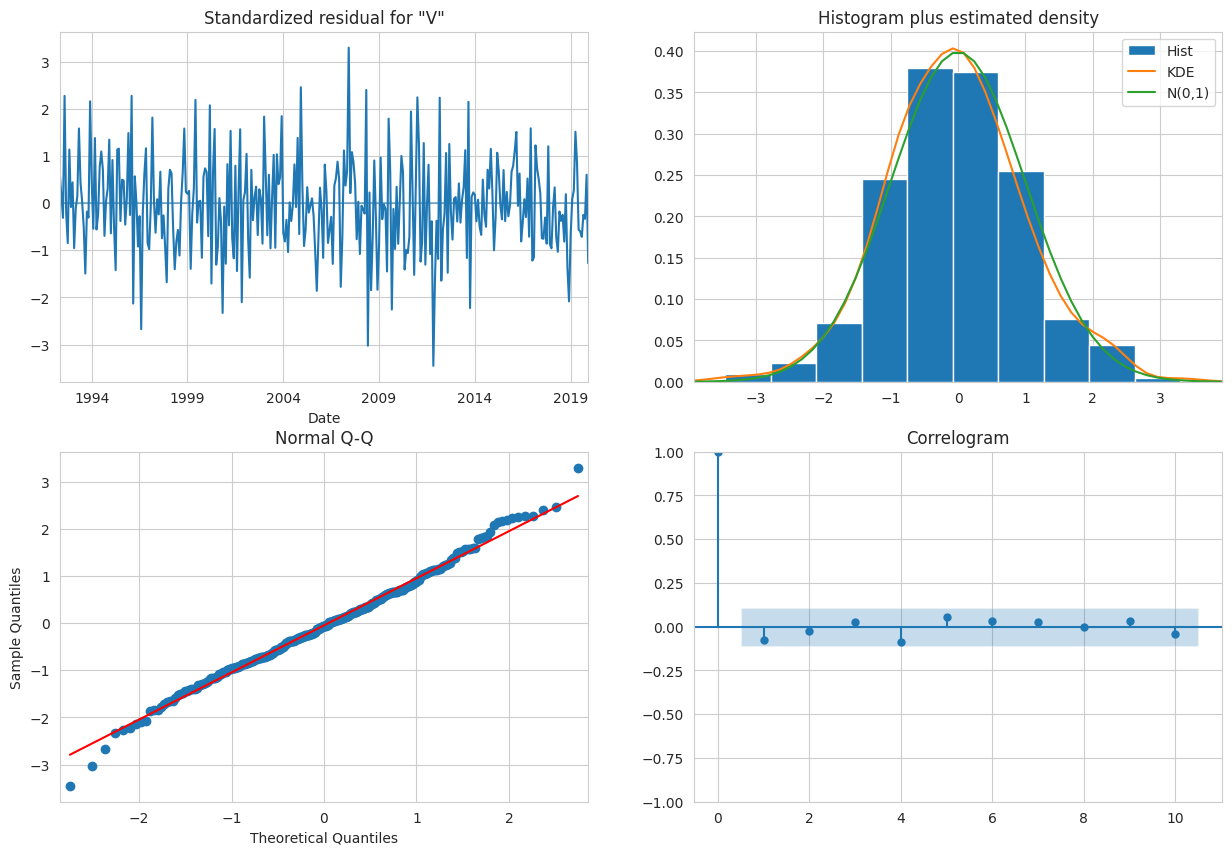

In [ ]:
import matplotlib.pyplot as plt

#Plot the diagnostic graphs for the model_fit object
print("Plotting SARIMA model diagnostics...")
model_fit.plot_diagnostics(figsize=(15, 10))
plt.show()


We need to split the data into training and testing sets, perform a forecast using the trained SARIMA model, and then calculate common error metrics (RMSE, MAE) to quantitatively evaluate the model's performance.




Root Mean Squared Error (RMSE): 1.6868
Mean Absolute Error (MAE): 1.3378


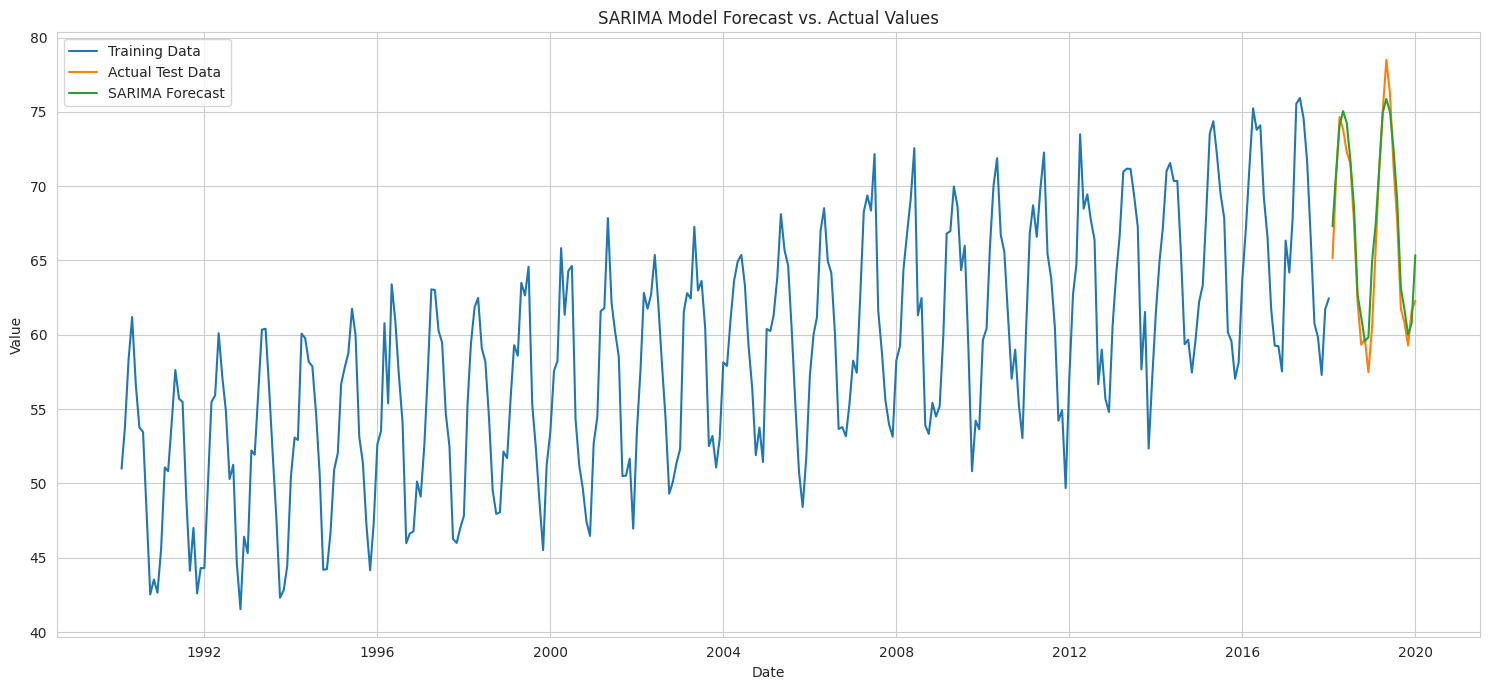

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#Split data into train and test sets
#Using the last 24 months (2 years) as the test set
train_data = df['Value'][:-24]
test_data = df['Value'][-24:]

#Retrain the model on the training data for forecasting
model_train = SARIMAX(train_data, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_train_fit = model_train.fit(disp=False)

#Generate predictions
start_index = len(train_data)
end_index = len(df['Value']) - 1
predictions = model_train_fit.predict(start=start_index, end=end_index, dynamic=False)

#Ensure predictions index matches test_data index for proper comparison
predictions.index = test_data.index

#Calculate error metrics
rmse = np.sqrt(mean_squared_error(test_data, predictions))
mae = mean_absolute_error(test_data, predictions)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

#Plot the forecast against actual values
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(predictions.index, predictions, label='SARIMA Forecast')
plt.title('SARIMA Model Forecast vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Forecast Next 6 Months and Visualize

6-month forecast:
2020-01-31    68.212226
2020-02-29    71.694482
2020-03-31    75.536678
2020-04-30    76.473196
2020-05-31    75.615248
2020-06-30    73.118784
Freq: ME, Name: predicted_mean, dtype: float64


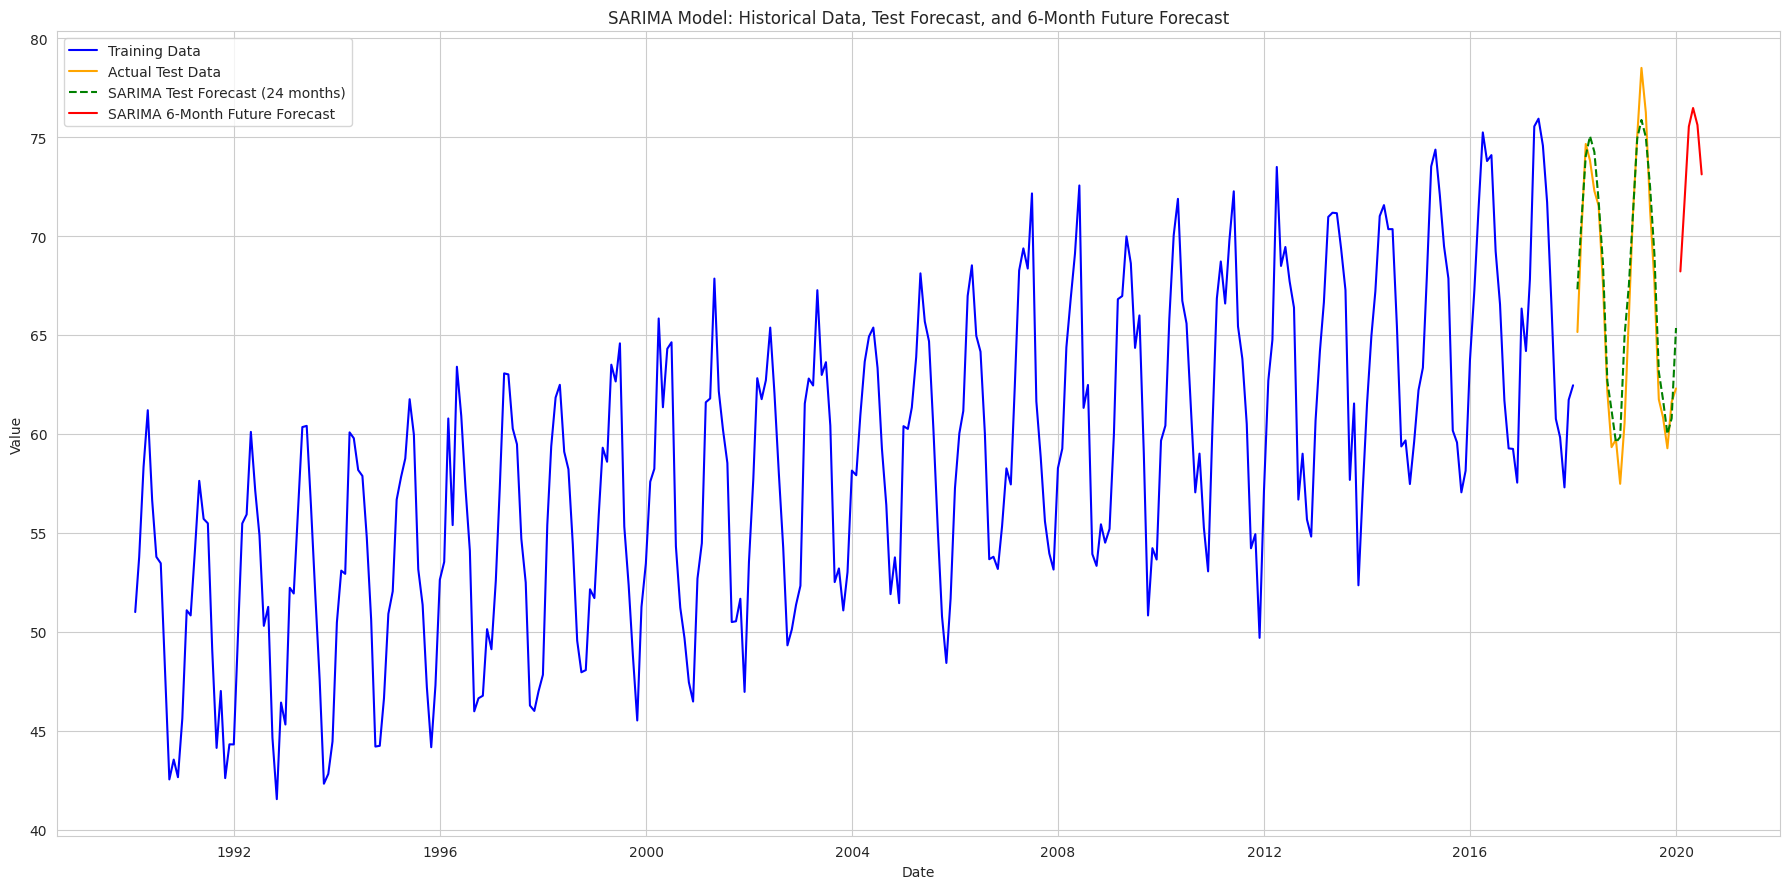

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Generate forecast for the next 6 months
forecast_start_index = len(df['Value'])
forecast_end_index = len(df['Value']) + 5 # 6 months beyond the last data point

#Create future dates for the forecast
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=7, freq='ME')[1:] # Start from the next month

#Generate the forecast
forecast_6_months = model_train_fit.predict(start=forecast_start_index, end=forecast_end_index)
forecast_6_months.index = future_dates

print("6-month forecast:")
print(forecast_6_months)

#Plot the historical training data, actual test data, previous forecast, and the new 6-month forecast
plt.figure(figsize=(18, 9))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(predictions.index, predictions, label='SARIMA Test Forecast (24 months)', color='green', linestyle='--')
plt.plot(forecast_6_months.index, forecast_6_months, label='SARIMA 6-Month Future Forecast', color='red')

plt.title('SARIMA Model: Historical Data, Test Forecast, and 6-Month Future Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Train and Evaluate SARMA Model

Train a SARMA model (SARIMA with d=0 and D=0) using the same training data and evaluate its performance on the test set by calculating RMSE and MAE.


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#Define SARMA model parameters (d=0 and D=0)
sarma_order = (1, 0, 2)  #d=0

#Seasonal (P, D, Q, s)
sarma_seasonal_order = (1, 0, 1, 12) #D=0

print(f"SARMA Model Order: {sarma_order}")
print(f"SARMA Seasonal Order: {sarma_seasonal_order}")

#Instantiate and train the SARMA model on the training data
model_sarma = SARIMAX(train_data, order=sarma_order, seasonal_order=sarma_seasonal_order, enforce_stationarity=True, enforce_invertibility=True)
model_sarma_fit = model_sarma.fit(disp=False) # Set disp=False to suppress convergence messages

#Print the model summary
print(model_sarma_fit.summary())

SARMA Model Order: (1, 0, 2)
SARMA Seasonal Order: (1, 0, 1, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                      SARIMAX Results                                       
Dep. Variable:                                Value   No. Observations:                  336
Model:             SARIMAX(1, 0, 2)x(1, 0, [1], 12)   Log Likelihood                -737.046
Date:                              Mon, 06 Jul 2026   AIC                           1486.091
Time:                                      19:44:58   BIC                           1508.994
Sample:                                  01-31-1990   HQIC                          1495.221
                                       - 12-31-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9981      0.002    435.938      0.000       0.994       1.003
ma.L1         -1.00

**Reasoning**:
Use the trained SARMA model (`model_sarma_fit`) to make predictions on the test set and then calculate the RMSE and MAE to evaluate its performance. This completes the evaluation part of the subtask.




SARIMA Model RMSE: 1.6868
SARIMA Model MAE: 1.3378

SARMA Model RMSE: 1.5249
SARMA Model MAE: 1.1806


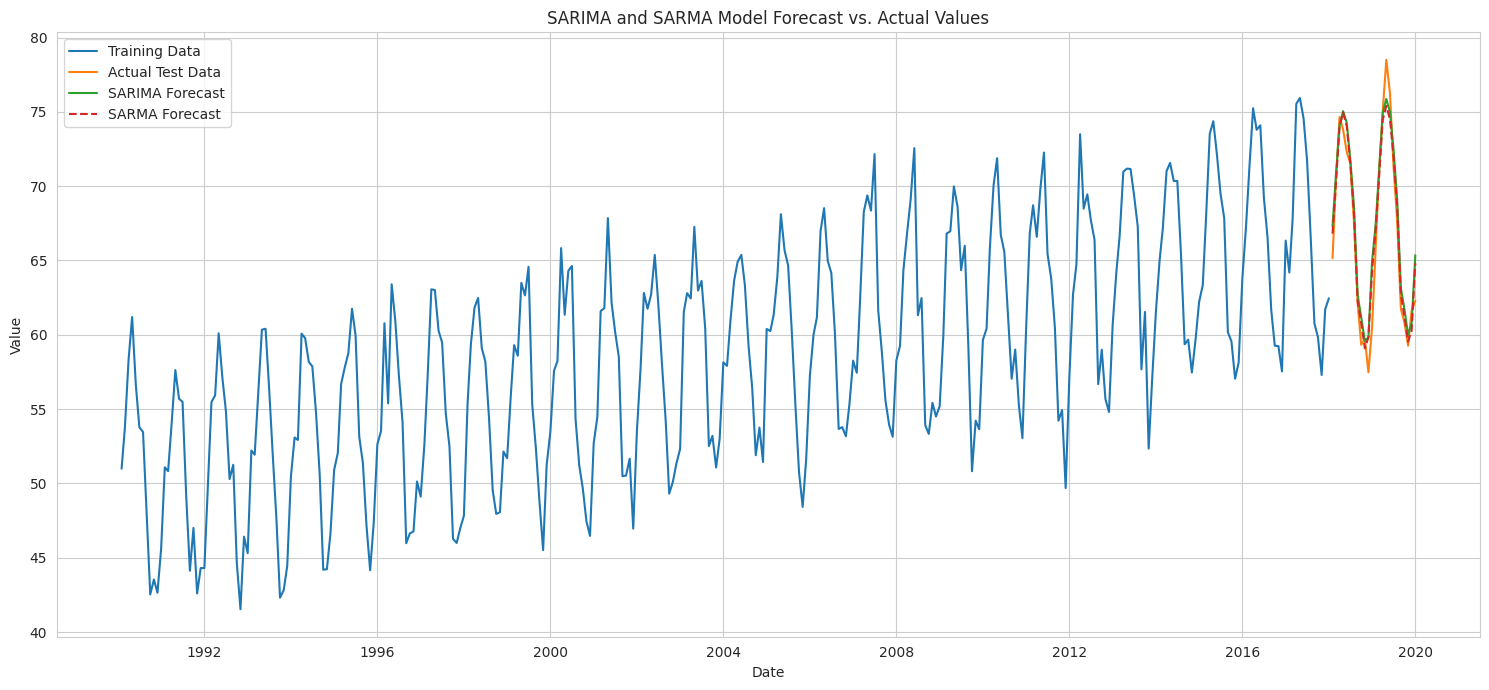

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#Split data into train and test sets
#Using the last 24 months (2 years) as the test set
train_data = df['Value'][:-24]
test_data = df['Value'][-24:]

#Retrain the model on the training data for forecasting (SARIMA model)
model_train = SARIMAX(train_data, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
model_train_fit = model_train.fit(disp=False)

#Generate predictions for SARIMA model
start_index = len(train_data)
end_index = len(df['Value']) - 1
predictions_sarima = model_train_fit.predict(start=start_index, end=end_index, dynamic=False)
predictions_sarima.index = test_data.index

#Calculate error metrics for SARIMA model
rmse_sarima = np.sqrt(mean_squared_error(test_data, predictions_sarima))
mae_sarima = mean_absolute_error(test_data, predictions_sarima)

print(f"\nSARIMA Model RMSE: {rmse_sarima:.4f}")
print(f"SARIMA Model MAE: {mae_sarima:.4f}")

#Generate predictions for SARMA model
predictions_sarma = model_sarma_fit.predict(start=start_index, end=end_index, dynamic=False)
predictions_sarma.index = test_data.index

#Calculate error metrics for SARMA model
rmse_sarma = np.sqrt(mean_squared_error(test_data, predictions_sarma))
mae_sarma = mean_absolute_error(test_data, predictions_sarma)

print(f"\nSARMA Model RMSE: {rmse_sarma:.4f}")
print(f"SARMA Model MAE: {mae_sarma:.4f}")

#Plot the forecast against actual values for both models
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(predictions_sarima.index, predictions_sarima, label='SARIMA Forecast')
plt.plot(predictions_sarma.index, predictions_sarma, label='SARMA Forecast', linestyle='--')
plt.title('SARIMA and SARMA Model Forecast vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Compare SARMA and SARIMA Performance
Present the performance metrics (RMSE, MAE) for both the SARIMA and SARMA models side-by-side and discuss which model exhibited better forecasting accuracy based on these metrics.


6-month SARMA forecast:
2020-01-31    67.606789
2020-02-29    71.048180
2020-03-31    74.908891
2020-04-30    75.841405
2020-05-31    74.937565
2020-06-30    72.438819
Freq: ME, Name: predicted_mean, dtype: float64


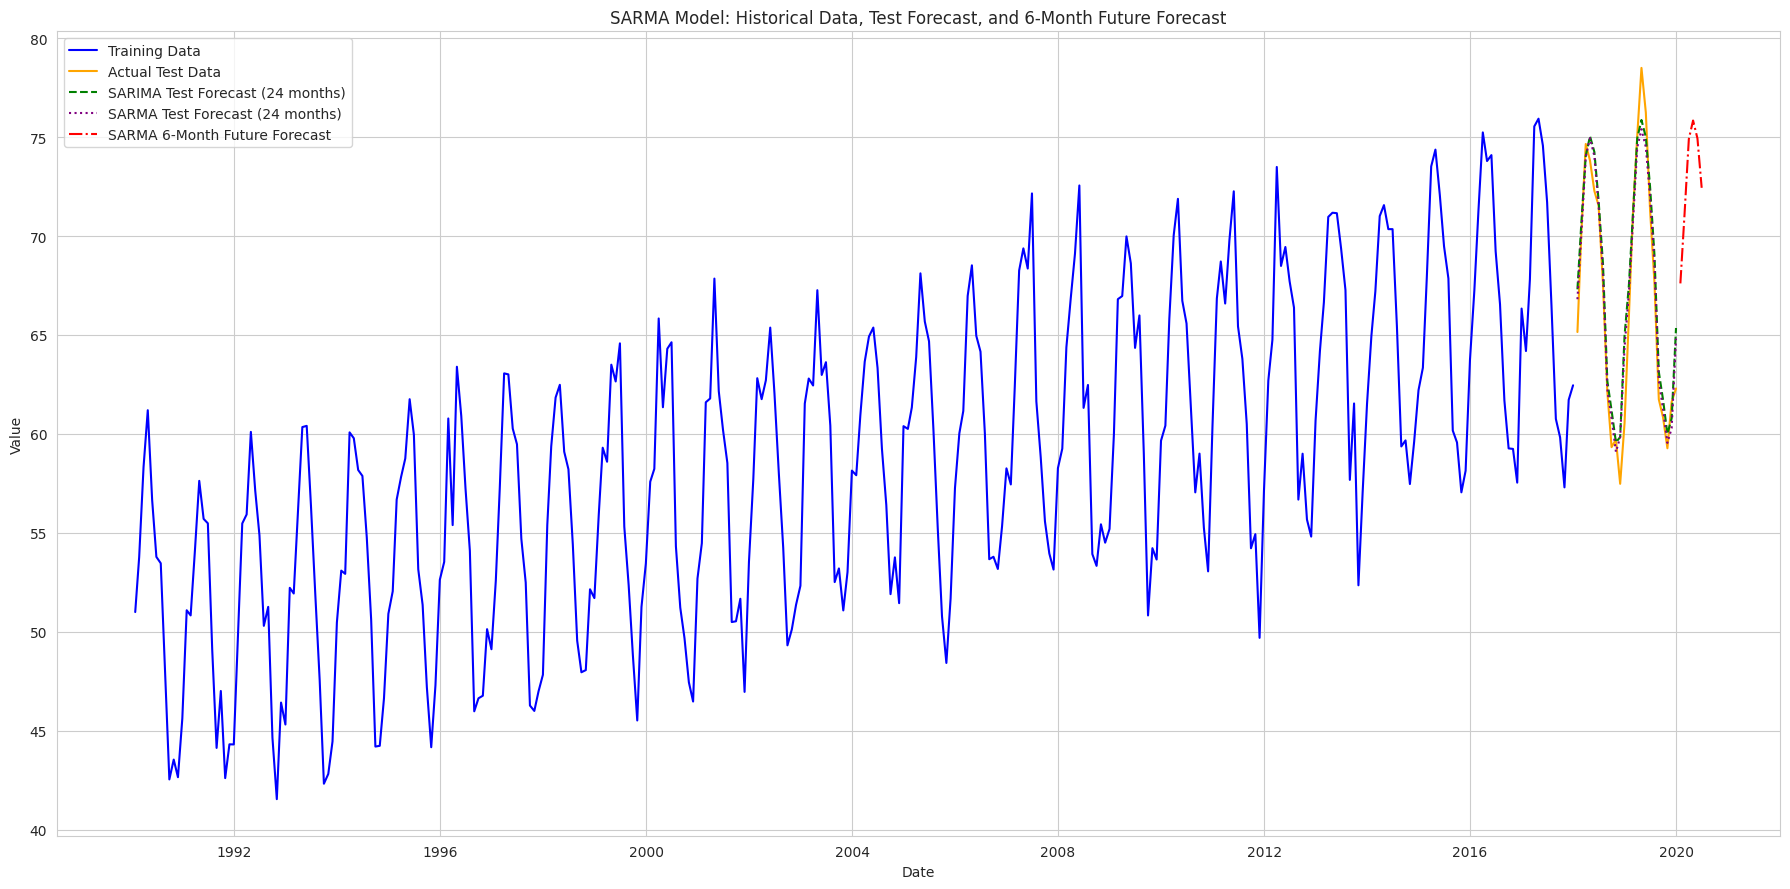

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Generate forecast for the next 6 months using the SARMA model
forecast_start_index_sarma = len(df['Value'])
forecast_end_index_sarma = len(df['Value']) + 5 # 6 months beyond the last data point

#Create future dates for the forecast, starting from the month after the last date in df
last_date_df = df.index[-1]
future_dates_sarma = pd.date_range(start=last_date_df, periods=7, freq='ME')[1:] # Start from the next month

#Generate the forecast
forecast_6_months_sarma = model_sarma_fit.predict(start=forecast_start_index_sarma, end=forecast_end_index_sarma)
forecast_6_months_sarma.index = future_dates_sarma

print("6-month SARMA forecast:")
print(forecast_6_months_sarma)

#Plot the historical training data, actual test data, previous SARIMA/SARMA forecasts, and the new 6-month SARMA forecast
plt.figure(figsize=(18, 9))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(predictions_sarima.index, predictions_sarima, label='SARIMA Test Forecast (24 months)', color='green', linestyle='--')
plt.plot(predictions_sarma.index, predictions_sarma, label='SARMA Test Forecast (24 months)', color='purple', linestyle=':')
plt.plot(forecast_6_months_sarma.index, forecast_6_months_sarma, label='SARMA 6-Month Future Forecast', color='red', linestyle='-.')

plt.title('SARMA Model: Historical Data, Test Forecast, and 6-Month Future Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

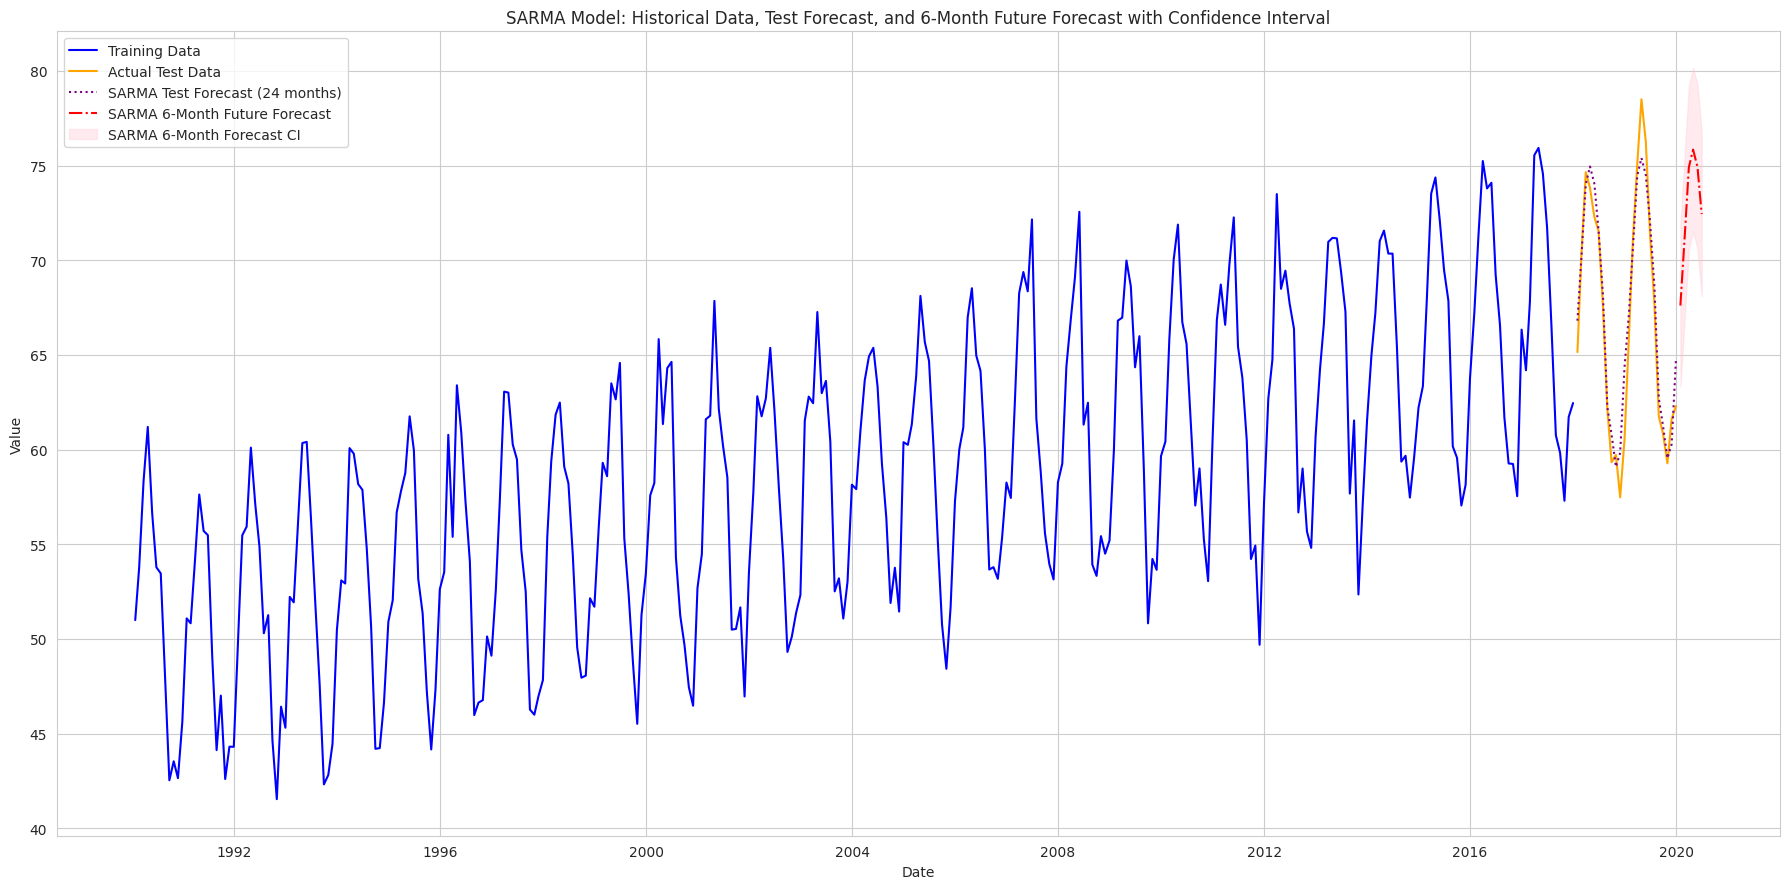

In [ ]:
import matplotlib.pyplot as plt

total_steps_for_ci = len(test_data) + 6
full_forecast_results_for_ci = model_sarma_fit.get_forecast(steps=total_steps_for_ci)

#Extract only the confidence intervals for the last 6 months (the future forecast period)
forecast_ci_sarma = full_forecast_results_for_ci.conf_int().iloc[-6:]

forecast_ci_sarma.index = forecast_6_months_sarma.index

#Plot the historical training data, actual test data, SARMA forecast, and confidence intervals
plt.figure(figsize=(18, 9))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(predictions_sarma.index, predictions_sarma, label='SARMA Test Forecast (24 months)', color='purple', linestyle=':')
plt.plot(forecast_6_months_sarma.index, forecast_6_months_sarma, label='SARMA 6-Month Future Forecast', color='red', linestyle='-.')
plt.fill_between(forecast_ci_sarma.index, forecast_ci_sarma.iloc[:, 0], forecast_ci_sarma.iloc[:, 1], color='pink', alpha=0.3, label='SARMA 6-Month Forecast CI')

plt.title('SARMA Model: Historical Data, Test Forecast, and 6-Month Future Forecast with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

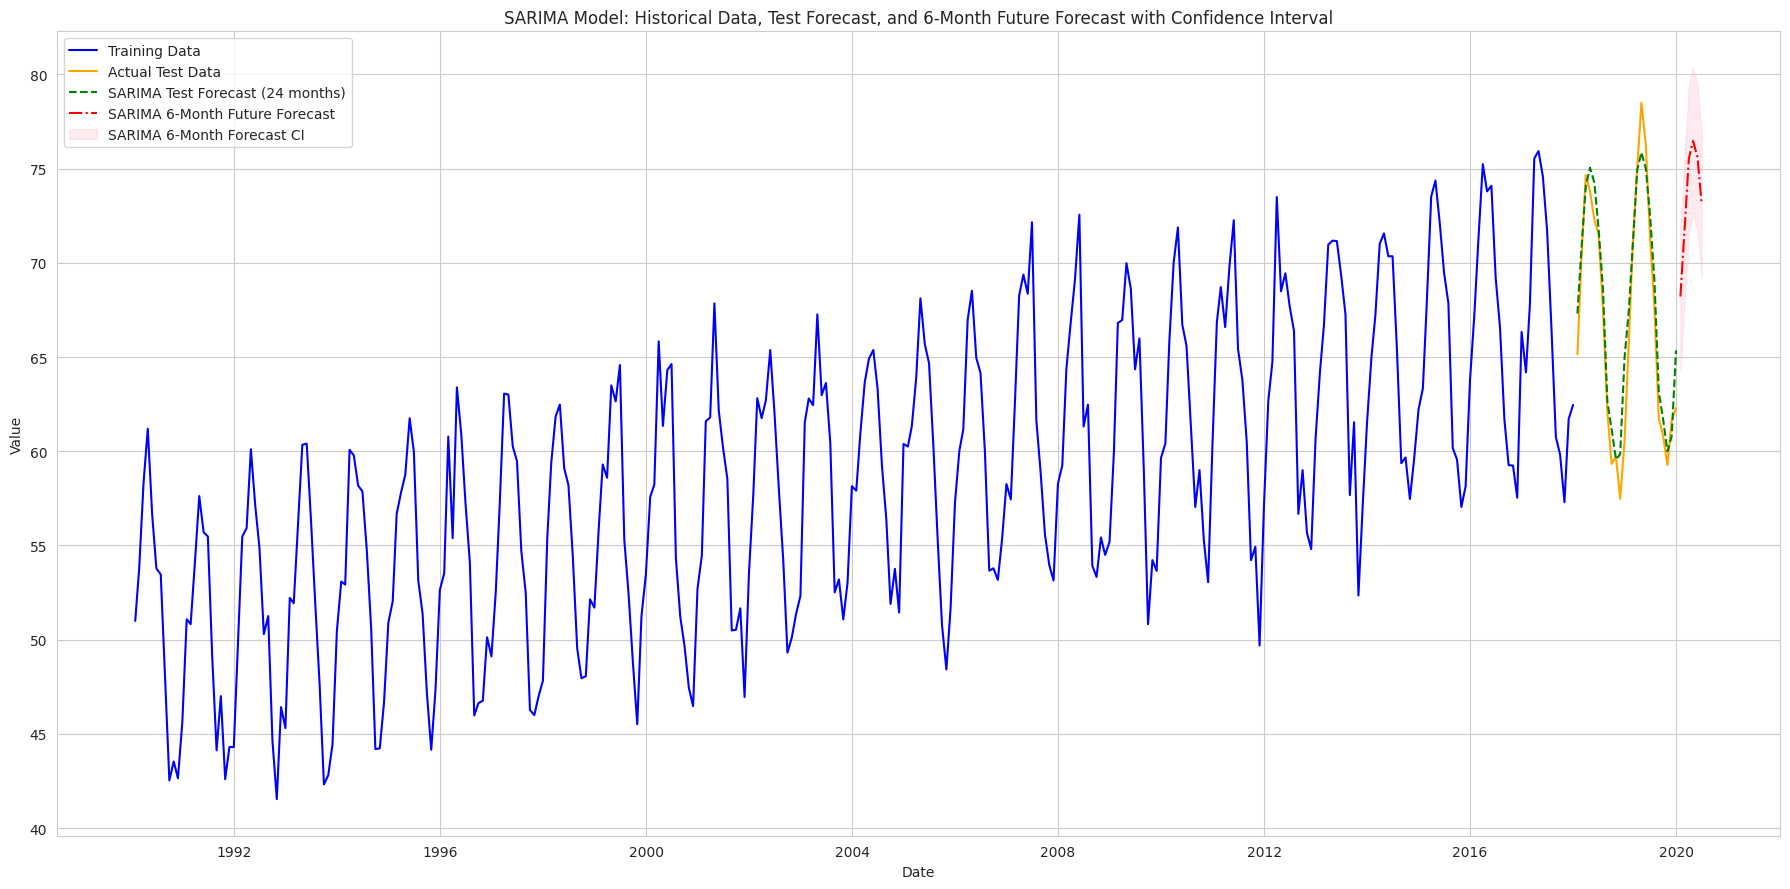

In [ ]:
import matplotlib.pyplot as plt


#Get the forecast with confidence intervals for the SARIMA model
full_forecast_results_sarima = model_train_fit.get_forecast(steps=total_steps_for_ci)

#Extract only the confidence intervals for the last 6 months (the future forecast period)
forecast_ci_sarima = full_forecast_results_sarima.conf_int().iloc[-6:]

#Ensure the index of the confidence intervals matches the index of the forecast_6_months
forecast_ci_sarima.index = forecast_6_months.index

#Plot the historical training data, actual test data, SARIMA test forecast, and 6-month future forecast with CI
plt.figure(figsize=(18, 9))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(predictions_sarima.index, predictions_sarima, label='SARIMA Test Forecast (24 months)', color='green', linestyle='--')
plt.plot(forecast_6_months.index, forecast_6_months, label='SARIMA 6-Month Future Forecast', color='red', linestyle='-.')
plt.fill_between(forecast_ci_sarima.index, forecast_ci_sarima.iloc[:, 0], forecast_ci_sarima.iloc[:, 1], color='pink', alpha=0.3, label='SARIMA 6-Month Forecast CI')

plt.title('SARIMA Model: Historical Data, Test Forecast, and 6-Month Future Forecast with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Train and Evaluate ARMAX-ARCH Model

Train an ARMAX model with ARCH errors (ARMAX-ARCH) using the non-seasonal AR and MA orders from the previously identified SARMA model. Evaluate its forecasting performance on the test set by calculating the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) of its conditional mean predictions.


In [ ]:
from arch import arch_model

print(f"ARMAX-ARCH Model Mean Order (p, q): ({sarma_order[0]}, {sarma_order[2]})")

model_arch = arch_model(train_data, p=sarma_order[0], q=sarma_order[2], vol='ARCH', power=2.0, dist='normal')
model_arch_fit = model_arch.fit(disp='off') #Set disp='off' to suppress convergence messages

#Print the model summary
print(model_arch_fit.summary())


ARMAX-ARCH Model Mean Order (p, q): (1, 2)
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  Value   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -1105.77
Distribution:                  Normal   AIC:                           2217.54
Method:            Maximum Likelihood   BIC:                           2228.99
                                        No. Observations:                  336
Date:                Mon, Jul 06 2026   Df Residuals:                      335
Time:                        19:45:04   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            58.5620      


ARMAX-ARCH Model RMSE: 10.4199
ARMAX-ARCH Model MAE: 8.4440


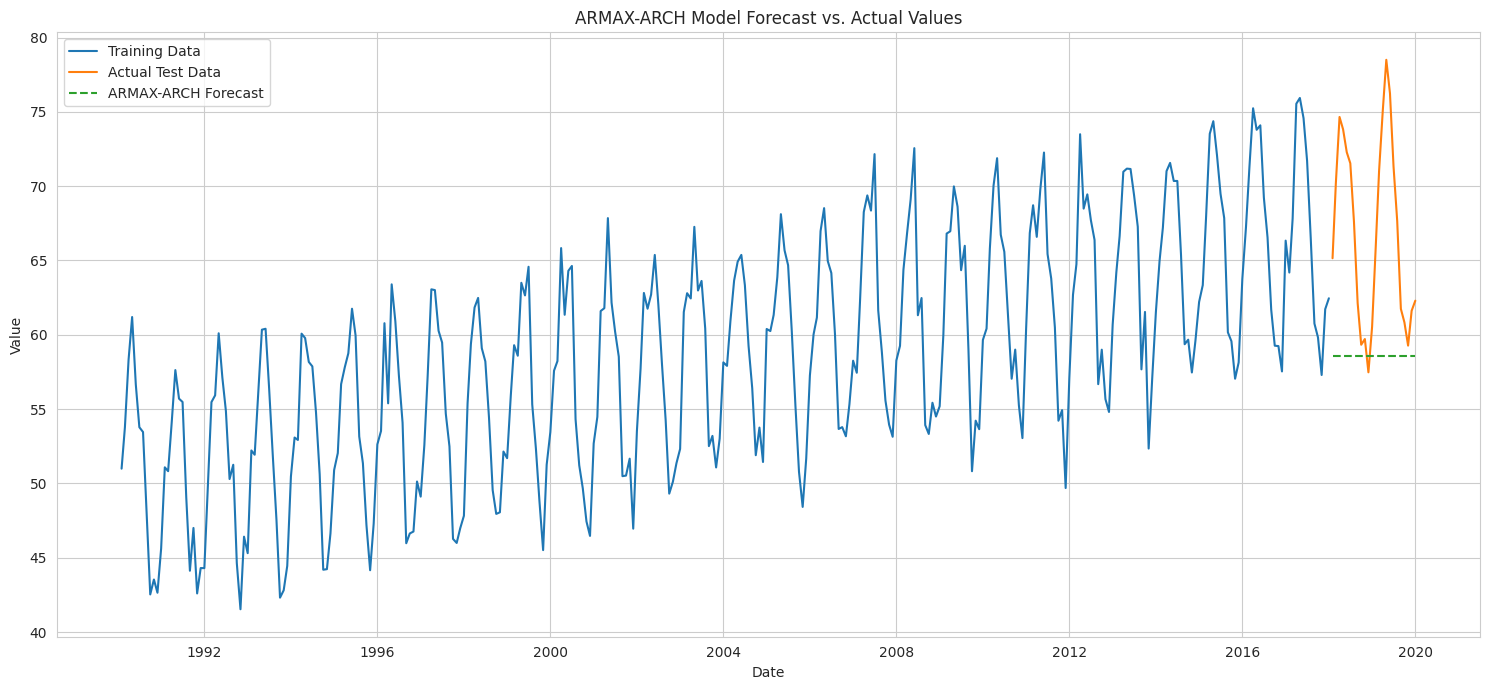

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

forecast_horizon = len(test_data)
arch_forecast = model_arch_fit.forecast(horizon=forecast_horizon)

predictions_arch = arch_forecast.mean.iloc[0]

predictions_arch.index = test_data.index

#Calculate error metrics for ARMAX-ARCH model
rmse_arch = np.sqrt(mean_squared_error(test_data, predictions_arch))
mae_arch = mean_absolute_error(test_data, predictions_arch)

print(f"\nARMAX-ARCH Model RMSE: {rmse_arch:.4f}")
print(f"ARMAX-ARCH Model MAE: {mae_arch:.4f}")

#Plot the forecast against actual values
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(predictions_arch.index, predictions_arch, label='ARMAX-ARCH Forecast', linestyle='--')
plt.title('ARMAX-ARCH Model Forecast vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Train and Evaluate ARMAX-GARCH Model

Train an ARMAX model with GARCH errors (ARMAX-GARCH) using the non-seasonal AR and MA orders from the previously identified SARMA model. Evaluate its forecasting performance on the test set by calculating the Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) of its conditional mean predictions.


In [ ]:
from arch import arch_model


print(f"ARMAX-GARCH Model Mean Order (p, q): ({sarma_order[0]}, {sarma_order[2]})")

#Instantiate and train the ARMAX-GARCH model on the training data
model_garch = arch_model(train_data, p=sarma_order[0], q=sarma_order[2], vol='Garch', power=2.0, dist='normal')
model_garch_fit = model_garch.fit(disp='off') # Set disp='off' to suppress convergence messages

#Print the model summary
print(model_garch_fit.summary())

ARMAX-GARCH Model Mean Order (p, q): (1, 2)
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Value   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1105.77
Distribution:                  Normal   AIC:                           2221.54
Method:            Maximum Likelihood   BIC:                           2240.62
                                        No. Observations:                  336
Date:                Mon, Jul 06 2026   Df Residuals:                      335
Time:                        19:45:05   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            58.5620     

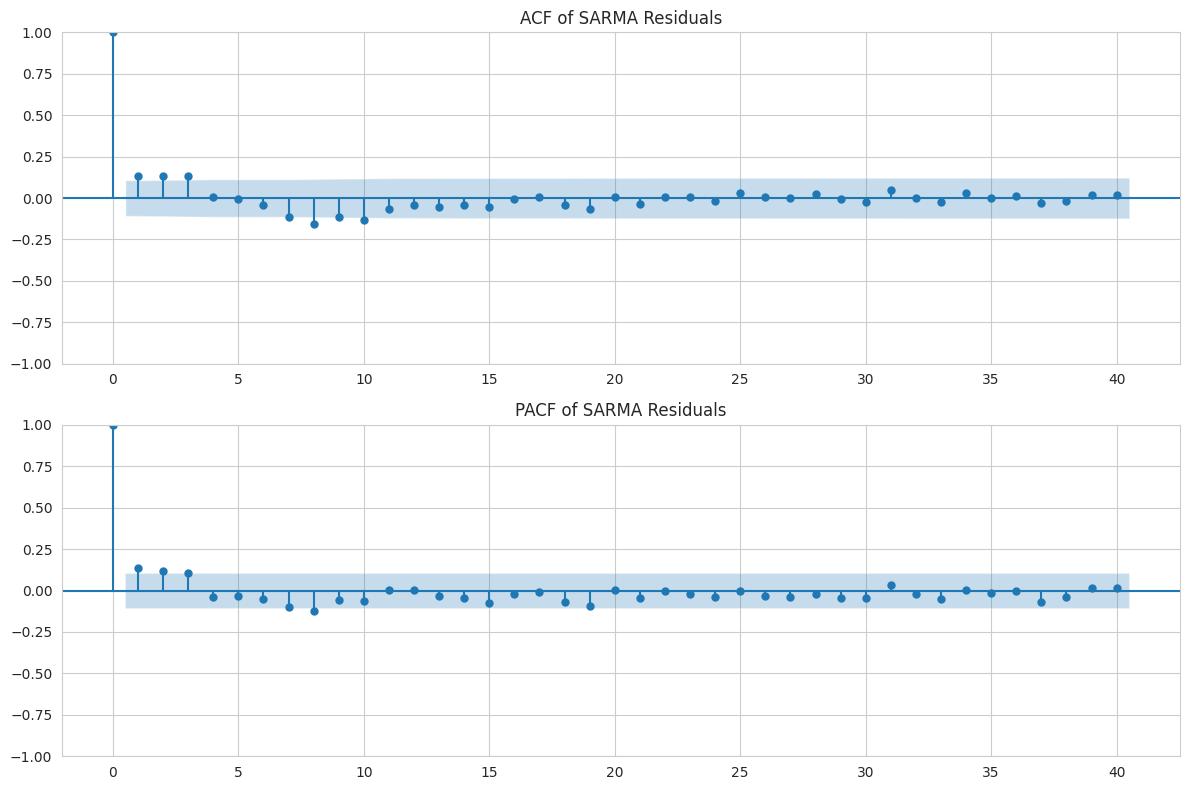

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Get the residuals from the SARMA model
sarma_residuals = model_sarma_fit.resid

#Plot ACF and PACF of the SARMA residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(sarma_residuals, ax=axes[0], lags=40)
axes[0].set_title('ACF of SARMA Residuals')

plot_pacf(sarma_residuals, ax=axes[1], lags=40)
axes[1].set_title('PACF of SARMA Residuals')

plt.tight_layout()
plt.show()

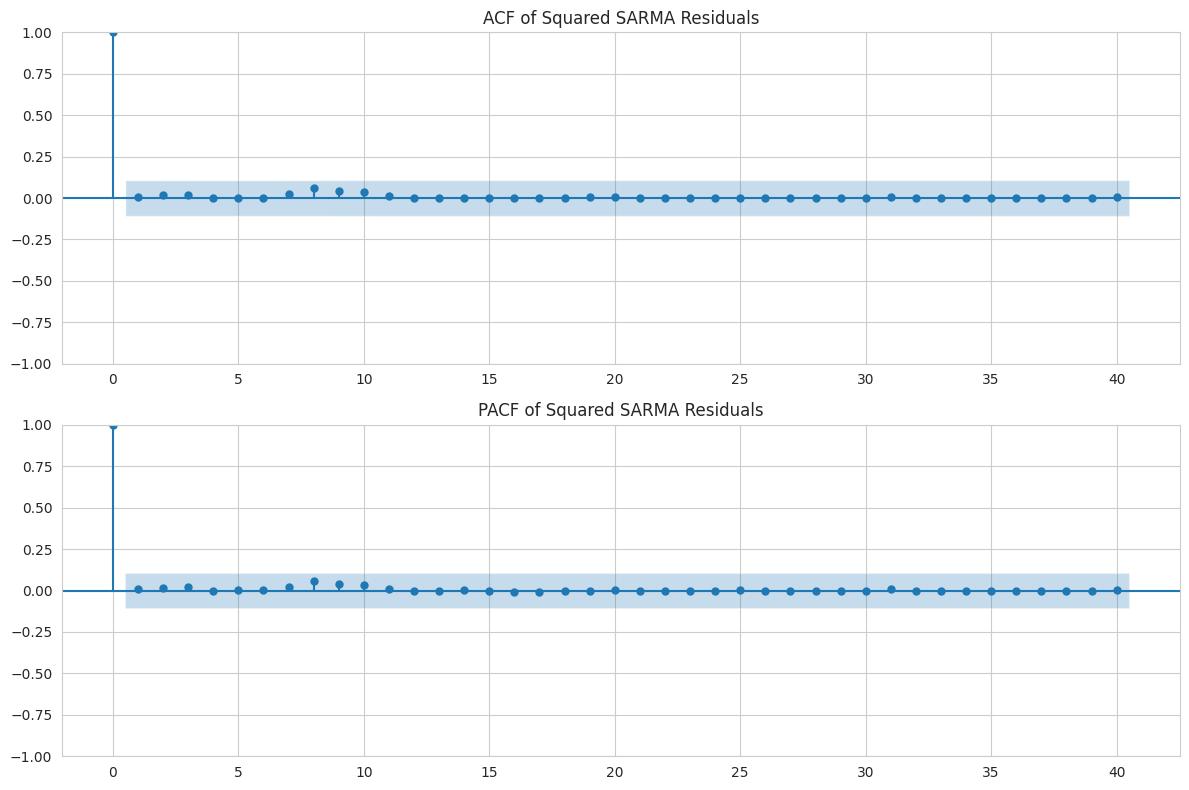

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Get the squared residuals from the SARMA model
sarma_squared_residuals = model_sarma_fit.resid**2

#Plot ACF and PACF of the squared SARMA residuals
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(sarma_squared_residuals, ax=axes[0], lags=40)
axes[0].set_title('ACF of Squared SARMA Residuals')

plot_pacf(sarma_squared_residuals, ax=axes[1], lags=40)
axes[1].set_title('PACF of Squared SARMA Residuals')

plt.tight_layout()
plt.show()

### Fit GARCH(1,1) Model to SARMA Residuals

In [ ]:
from arch import arch_model

#Fit a GARCH(1,1) model to the SARMA residuals
model_garch_residuals = arch_model(sarma_residuals, mean='Zero', vol='Garch', p=1, q=1, dist='normal')
model_garch_residuals_fit = model_garch_residuals.fit(disp='off')

#Print the model summary
print(model_garch_residuals_fit.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.003
Vol Model:                      GARCH   Log-Likelihood:               -746.106
Distribution:                  Normal   AIC:                           1498.21
Method:            Maximum Likelihood   BIC:                           1509.66
                                        No. Observations:                  336
Date:                Mon, Jul 06 2026   Df Residuals:                      336
Time:                        19:45:06   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.6527      0.115      5.678  1.362e-08 

### Visualize Conditional Volatility from GARCH(1,1) Model


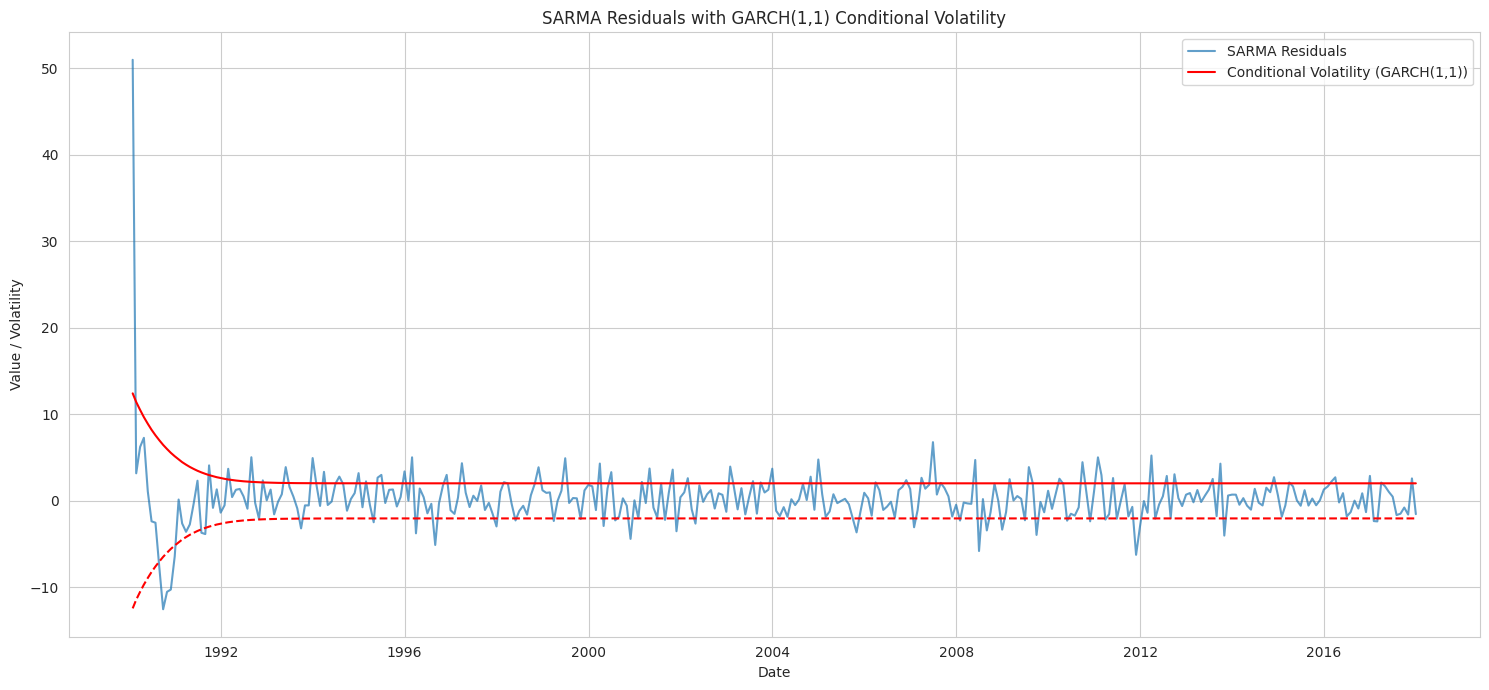

In [ ]:
import matplotlib.pyplot as plt

#Get the conditional volatility (standard deviation) from the GARCH model
conditional_volatility = model_garch_residuals_fit.conditional_volatility

#Plot the SARMA residuals and the conditional volatility
plt.figure(figsize=(15, 7))
plt.plot(sarma_residuals.index, sarma_residuals, label='SARMA Residuals', alpha=0.7)
plt.plot(conditional_volatility.index, conditional_volatility, label='Conditional Volatility (GARCH(1,1))', color='red')
plt.plot(conditional_volatility.index, -conditional_volatility, color='red', linestyle='--', label='_nolegend_') # Plot negative volatility for bounds

plt.title('SARMA Residuals with GARCH(1,1) Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Value / Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ARMAX-GARCH Model RMSE: 10.4198
ARMAX-GARCH Model MAE: 8.4440


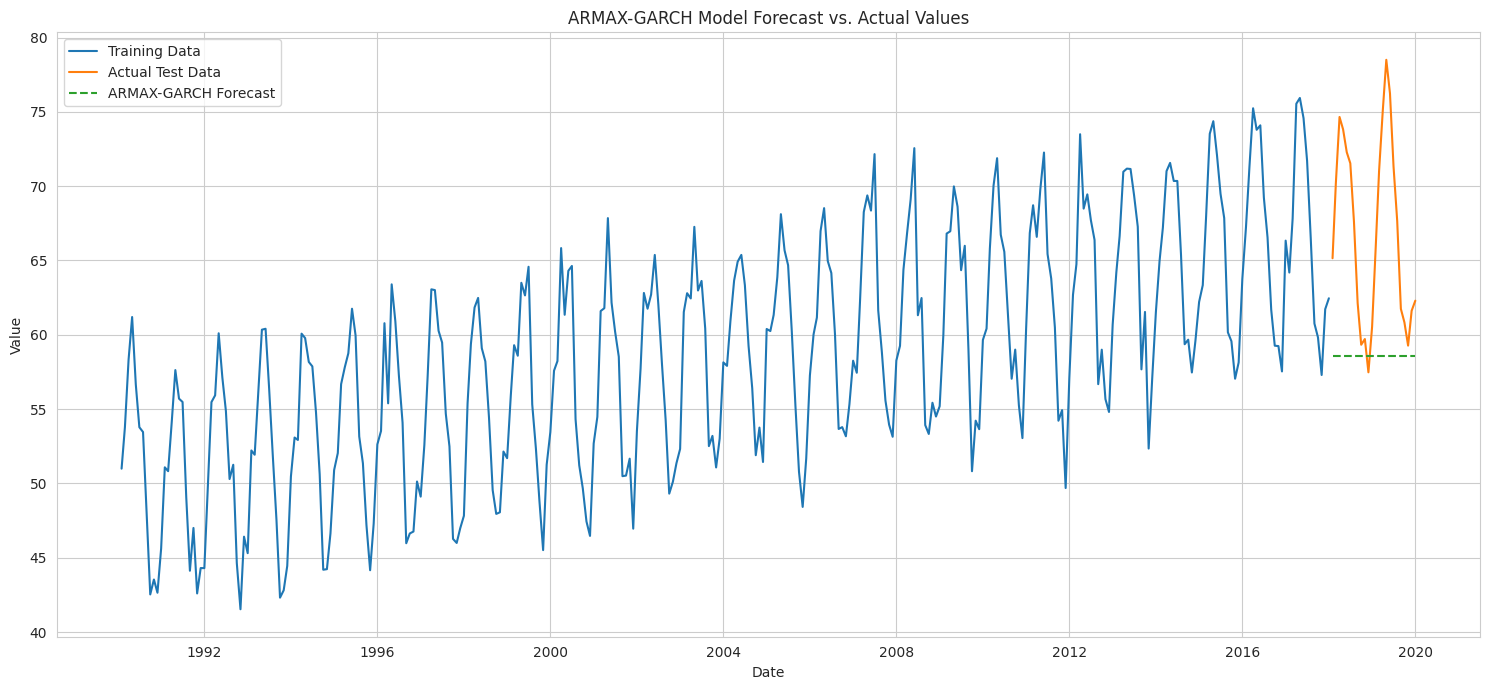

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

forecast_horizon = len(test_data)
garch_forecast = model_garch_fit.forecast(horizon=forecast_horizon)

predictions_garch = garch_forecast.mean.iloc[0]

predictions_garch.index = test_data.index

#Calculate error metrics for ARMAX-GARCH model
rmse_garch = np.sqrt(mean_squared_error(test_data, predictions_garch))
mae_garch = mean_absolute_error(test_data, predictions_garch)

print(f"\nARMAX-GARCH Model RMSE: {rmse_garch:.4f}")
print(f"ARMAX-GARCH Model MAE: {mae_garch:.4f}")

#Plot the forecast against actual values
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Actual Test Data')
plt.plot(predictions_garch.index, predictions_garch, label='ARMAX-GARCH Forecast', linestyle='--')
plt.title('ARMAX-GARCH Model Forecast vs. Actual Values')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

## Compare All Model Performances


In [ ]:
import pandas as pd

#Create a dictionary to store the performance metrics
performance_metrics = {
    'Model': ['SARIMA', 'SARMA', 'ARMAX-ARCH', 'ARMAX-GARCH'],
    'RMSE': [rmse_sarima, rmse_sarma, rmse_arch, rmse_garch],
    'MAE': [mae_sarima, mae_sarma, mae_arch, mae_garch],
    'AIC': [model_train_fit.aic, model_sarma_fit.aic, model_arch_fit.aic, model_garch_fit.aic],
    'BIC': [model_train_fit.bic, model_sarma_fit.bic, model_arch_fit.bic, model_garch_fit.bic]
}

#Create a DataFrame from the dictionary
df_performance = pd.DataFrame(performance_metrics)

df_performance.set_index('Model', inplace=True)

print("\nModel Performance Comparison:")
print(df_performance.round(4))


Model Performance Comparison:
                RMSE     MAE        AIC        BIC
Model                                             
SARIMA        1.6868  1.3378  1317.5482  1339.9288
SARMA         1.5249  1.1806  1486.0914  1508.9940
ARMAX-ARCH   10.4199  8.4440  2217.5373  2228.9887
ARMAX-GARCH  10.4198  8.4440  2221.5373  2240.6229


## Finding Optimal SARIMA Parameters with `auto_arima`

We will use `pmdarima.auto_arima` to automatically select the best `(p, d, q)(P, D, Q, s)` parameters for the SARIMA model.

In [ ]:
import pmdarima as pm

#Define the seasonal period
s = 12

#Use auto_arima to find the best SARIMA parameters
auto_sarima_model = pm.auto_arima(train_data,
                                  start_p=0, start_q=0,
                                  test='adf',
                                  max_p=5, max_q=5,
                                  m=s,
                                  start_P=0, start_Q=0,
                                  max_P=5, max_Q=5,
                                  d=1, D=1, #Fixed differencing orders as determined
                                  seasonal=True,
                                  trace=True,
                                  error_action='ignore',
                                  suppress_warnings=True,
                                  stepwise=True)

print(auto_sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1813.393, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1614.669, Time=0.21 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.38 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1706.807, Time=0.07 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1572.611, Time=0.44 sec
 ARIMA(1,1,0)(3,1,0)[12]             : AIC=1564.564, Time=0.92 sec
 ARIMA(1,1,0)(4,1,0)[12]             : AIC=1553.409, Time=1.62 sec
 ARIMA(1,1,0)(5,1,0)[12]             : AIC=1546.779, Time=4.90 sec
 ARIMA(1,1,0)(5,1,1)[12]             : AIC=1522.846, Time=13.32 sec
 ARIMA(1,1,0)(4,1,1)[12]             : AIC=1521.724, Time=7.12 sec
 ARIMA(1,1,0)(3,1,1)[12]             : AIC=inf, Time=9.24 sec
 ARIMA(1,1,0)(4,1,2)[12]             : AIC=inf, Time=14.59 sec
 ARIMA(1,1,0)(3,1,2)[12]             : AIC=inf, Time=5.20 sec
 ARIMA(1,1,0)(5,1,2)[12]             : AIC=1525.638, Time=19.23 sec
 ARIMA(0,1,0)(4,1,1)[12]            

## Finding Optimal SARMA Parameters with `auto_arima`

We will use `pmdarima.auto_arima` to automatically select the best `(p, 0, q)(P, 0, Q, s)` parameters for the SARMA model. We will set `d=0` and `D=0` to reflect no differencing.

In [ ]:
import pmdarima as pm

# Define the seasonal period
s = 12

#Use auto_arima to find the best SARMA parameters
auto_sarma_model = pm.auto_arima(train_data,
                                 start_p=0, start_q=0,
                                 test='adf',
                                 max_p=5, max_q=5,
                                 m=s,
                                 start_P=0, start_Q=0,
                                 max_P=5, max_Q=5,
                                 d=0, D=0, #Fixed differencing orders for SARMA
                                 seasonal=True,
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

print(auto_sarma_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=2325.014, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.87 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1933.165, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3694.611, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=2065.727, Time=0.12 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=1664.337, Time=1.58 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1670.618, Time=1.05 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=4.96 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=3.44 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1862.814, Time=1.15 sec
 ARIMA(0,0,1)(2,0,0)[12] intercept   : AIC=1776.681, Time=3.08 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=6.22 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=1612.944, Time=1.40 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=2069.014, Time=0.22 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : 

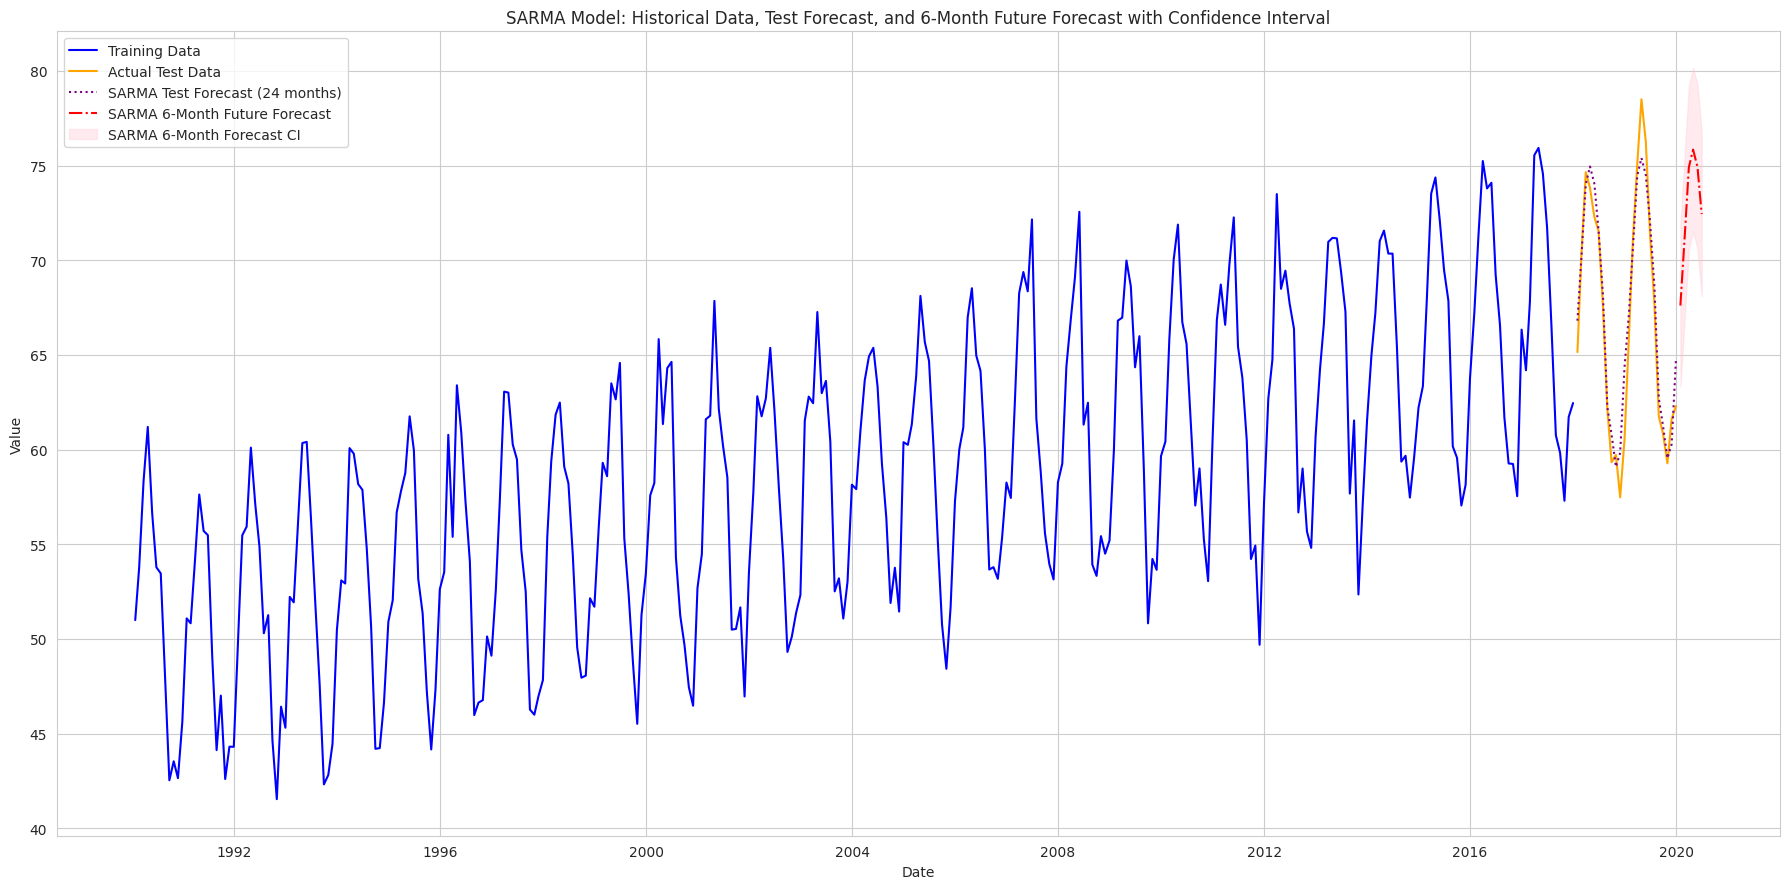

In [ ]:
import matplotlib.pyplot as plt

total_steps_for_ci = len(test_data) + 6
full_forecast_results_for_ci = model_sarma_fit.get_forecast(steps=total_steps_for_ci)

#Extract only the confidence intervals for the last 6 months (the future forecast period)
forecast_ci_sarma = full_forecast_results_for_ci.conf_int().iloc[-6:]

#Ensure the index of the confidence intervals matches the index of the forecast_6_months_sarma
forecast_ci_sarma.index = forecast_6_months_sarma.index

#Plot the historical training data, actual test data, SARMA forecast, and confidence intervals
plt.figure(figsize=(18, 9))
plt.plot(train_data.index, train_data, label='Training Data', color='blue')
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')
plt.plot(predictions_sarma.index, predictions_sarma, label='SARMA Test Forecast (24 months)', color='purple', linestyle=':')
plt.plot(forecast_6_months_sarma.index, forecast_6_months_sarma, label='SARMA 6-Month Future Forecast', color='red', linestyle='-.')
plt.fill_between(forecast_ci_sarma.index, forecast_ci_sarma.iloc[:, 0], forecast_ci_sarma.iloc[:, 1], color='pink', alpha=0.3, label='SARMA 6-Month Forecast CI')

plt.title('SARMA Model: Historical Data, Test Forecast, and 6-Month Future Forecast with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

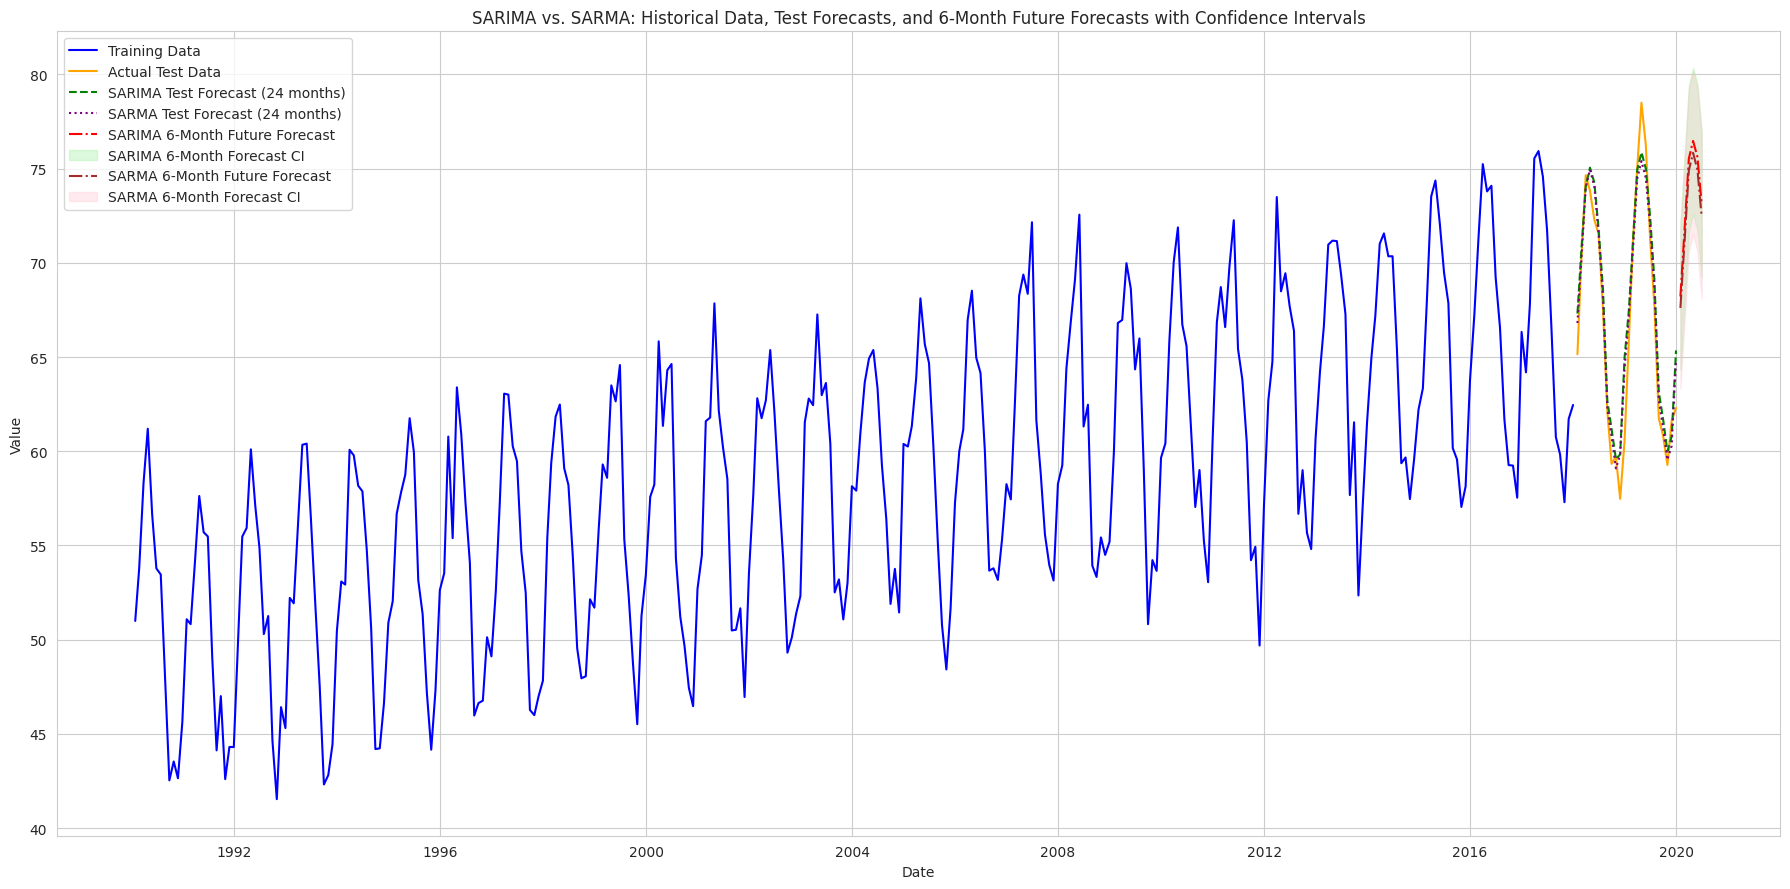

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

plt.plot(train_data.index, train_data, label='Training Data', color='blue')

plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange')

plt.plot(predictions_sarima.index, predictions_sarima, label='SARIMA Test Forecast (24 months)', color='green', linestyle='--')

plt.plot(predictions_sarma.index, predictions_sarma, label='SARMA Test Forecast (24 months)', color='purple', linestyle=':')

plt.plot(forecast_6_months.index, forecast_6_months, label='SARIMA 6-Month Future Forecast', color='red', linestyle='-.')

plt.fill_between(forecast_ci_sarima.index, forecast_ci_sarima.iloc[:, 0], forecast_ci_sarima.iloc[:, 1], color='lightgreen', alpha=0.3, label='SARIMA 6-Month Forecast CI')

plt.plot(forecast_6_months_sarma.index, forecast_6_months_sarma, label='SARMA 6-Month Future Forecast', color='brown', linestyle='-.')

plt.fill_between(forecast_ci_sarma.index, forecast_ci_sarma.iloc[:, 0], forecast_ci_sarma.iloc[:, 1], color='pink', alpha=0.3, label='SARMA 6-Month Forecast CI')

plt.title('SARIMA vs. SARMA: Historical Data, Test Forecasts, and 6-Month Future Forecasts with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()